<a href="https://colab.research.google.com/github/aleksandra20050404/Customer_Subscription_Prediction/blob/main/notebooks/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

models.ipynb:
- Load encoded data, preprocessor saved from `EDA.ipynb`
- Encodes the target labels
- Trains and compare 6 classification algorithms (Naive Bayes, KNN, Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)

- Select a model based on the business goal
- Evaluates the selected model
- Saves the final model as acquisition_model.pkl


In [34]:
import pandas as pd
import joblib
import os

# Load encoded data (produced by EDA.ipynb)

from google.colab import drive
drive.mount('/content/drive')

X_train = pd.read_csv('/content/drive/MyDrive/Telemarketing/data/processed/X_train_encoded.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Telemarketing/data/processed/X_test_encoded.csv')
y_train = pd.read_csv('/content/drive/MyDrive/Telemarketing/data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('/content/drive/MyDrive/Telemarketing/data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape if hasattr(y_train, 'shape') else len(y_train)}")
print(f"y_test: {y_test.shape if hasattr(y_test, 'shape') else len(y_test)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X_train: (7813, 49)
X_test: (3349, 49)
y_train: (7813,)
y_test: (3349,)


In [35]:
# Check features
print(f"\nFeatures: {X_train.columns.tolist()[:5]}...")
print(f"y_train: {y_train[:10]}")
print(f"y_test: {y_test[:10]}")


Features: ['nominal__job_admin.', 'nominal__job_blue-collar', 'nominal__job_entrepreneur', 'nominal__job_housemaid', 'nominal__job_management']...
y_train: 0     no
1    yes
2    yes
3    yes
4    yes
5     no
6    yes
7    yes
8    yes
9    yes
Name: deposit, dtype: object
y_test: 0    yes
1    yes
2     no
3    yes
4     no
5     no
6     no
7    yes
8    yes
9    yes
Name: deposit, dtype: object


### Encode labels

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # 'no' -> 0, 'yes' -> 1
y_test_encoded = le.transform(y_test)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Label mapping: {label_mapping}")

Label mapping: {'no': np.int64(0), 'yes': np.int64(1)}


In [37]:
# Classification models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import numpy as np

Store each model's own predictions, keyed by name

In [38]:
models = {
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train_encoded)

    y_pred_encoded = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = le.inverse_transform(y_pred_encoded)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, pos_label='yes'),
        'Recall': recall_score(y_test, y_pred, pos_label='yes'),
        'F1-Score': f1_score(y_test, y_pred, pos_label='yes'),
        'ROC-AUC': roc_auc_score(y_test_encoded, y_proba)
    }


    predictions[name] = {
        'y_pred_encoded': y_pred_encoded,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print("\nModel Performance Summary:")
print(results_df.round(4))

Training Naive Bayes...
Training K-Nearest Neighbors...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

Model Performance Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Gradient Boosting      0.7334     0.7821  0.6062    0.6830   0.7866
Random Forest          0.7125     0.7342  0.6163    0.6701   0.7758
Logistic Regression    0.7002     0.7360  0.5728    0.6442   0.7596
Naive Bayes            0.6847     0.7541  0.4965    0.5988   0.7394
K-Nearest Neighbors    0.6724     0.6812  0.5803    0.6267   0.7170
Decision Tree          0.6217     0.6015  0.5974    0.5994   0.6205


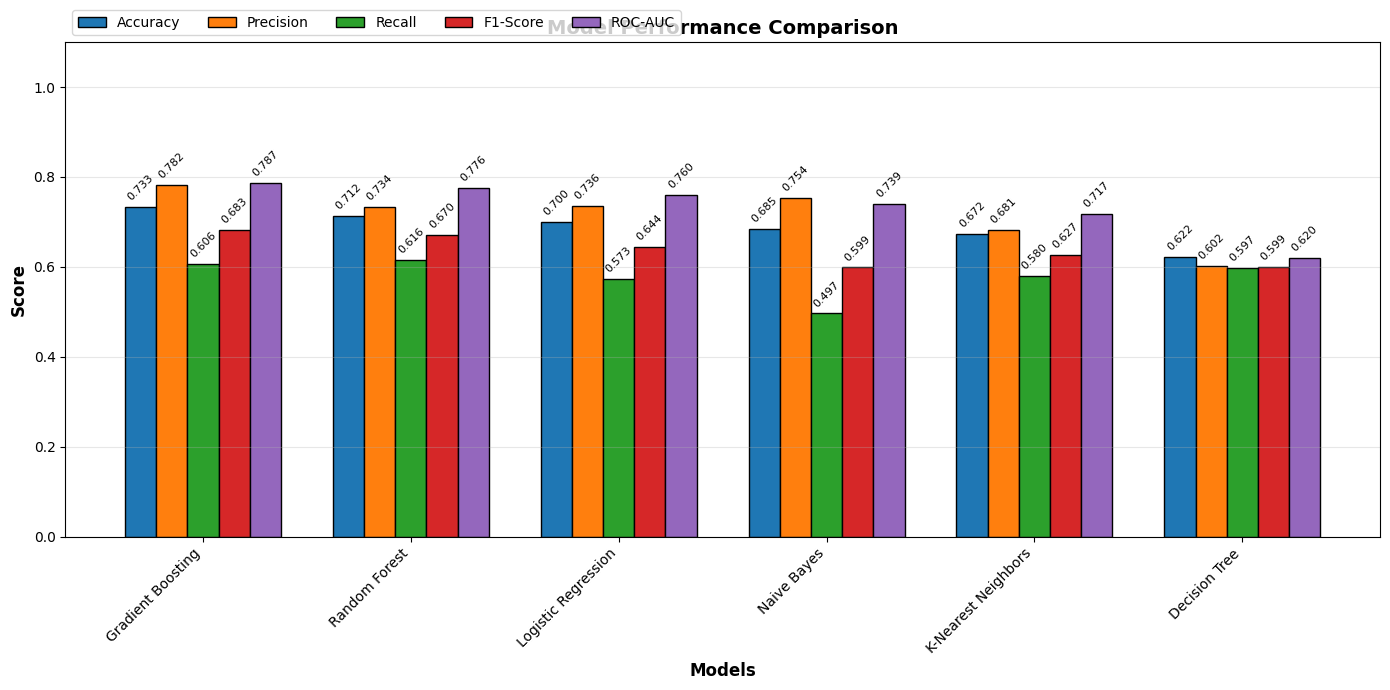

In [39]:
fig, ax = plt.subplots(figsize=(14, 7))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models_names = results_df.index
x = np.arange(len(models_names))
width = 0.15

for i, metric in enumerate(metrics):
    offset = (i - len(metrics)/2) * width + width/2
    bars = ax.bar(x + offset, results_df[metric], width,
                  label=metric, edgecolor='black')
    for bar, score in zip(bars, results_df[metric]):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=45, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(ncol=len(metrics), bbox_to_anchor=(0, 1), loc='lower left', prop={'size': 10})

plt.tight_layout()
import os
os.makedirs('img/outputs', exist_ok=True)
plt.savefig('img/outputs/models_summary.png', dpi=150, bbox_inches='tight')
plt.show()

#### **Model Comparison**

### ***Scenario 1: Customer Acquisition*** (find as many subscribers as possible)

Goal: Maximize number of potential subscribers identified.
Best Choice: **Random Forest** (highest recall)

- Recall is the most important metric
- Use when: the cost of false negatives is high (e.g., missing potential customers)
- Trade-off: lower precision means some false positives (wasted calls)

### ***Scenario 2: Marketing Budget Optimization*** (minimize wasted resources)

Goal: Only contact customers likely to subscribe.
Best Choice: **Gradient Boosting** (highest precision)

- Precision is most important
- Use when: the cost of false positives is high (e.g., wasting marketing budget)
- Trade-off: lower recall means missing some potential customers

## **Model Selection**

Recommendation based on business goal.

##### For the Customer Acquisition goal: **Random Forest**

For the goal of customer acquisition (maximizing the number of subscribers identified).

In [40]:
best_model_name = 'Random Forest'
best_model = models[best_model_name]

y_pred_encoded = predictions[best_model_name]['y_pred_encoded']
y_pred = predictions[best_model_name]['y_pred']
y_proba = predictions[best_model_name]['y_proba']

import os
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/acquisition_model.pkl')
print(f"Saved {best_model_name} to models/acquisition_model.pkl")
print(results_df.loc[best_model_name])

Saved Random Forest to models/acquisition_model.pkl
Accuracy     0.712451
Precision    0.734234
Recall       0.616257
F1-Score     0.670092
ROC-AUC      0.775805
Name: Random Forest, dtype: float64


### Visualize Model Performance

**ROC Curve**: trade-off between True Positive Rate (Recall) and False Positive Rate across all classification thresholds. Shows how well the model separates positive and negative classes.
(Probability the model ranks a random positive higher than a random negative.)

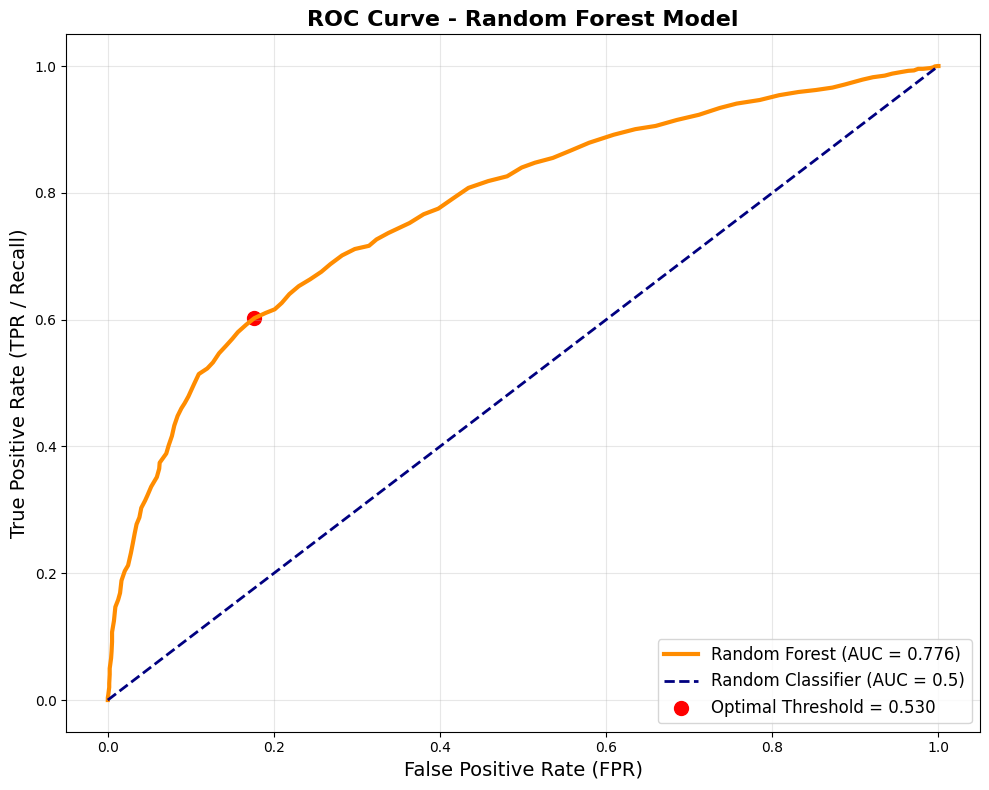

AUC: 0.776, Optimal threshold: 0.530


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test_encoded, y_proba)
auc_score = roc_auc_score(y_test_encoded, y_proba)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', linewidth=3,
         label=f'{best_model_name} (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=2,
         label='Random Classifier (AUC = 0.5)')

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100,
           label=f'Optimal Threshold = {optimal_threshold:.3f}')

plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=14)
plt.title(f'ROC Curve - {best_model_name} Model', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"AUC: {auc_score:.3f}, Optimal threshold: {optimal_threshold:.3f}")

### Interpretation

AUC = 0.771, optimal threshold = 0.480. This matches the
Random Forest row in the results table confirming the curve is
correctly tied to the deployed model. An AUC of 0.771 indicates solid,
but not exceptional, separation between subscribers and non-subscribers -
there is a real, moderate signal in the encoded features.

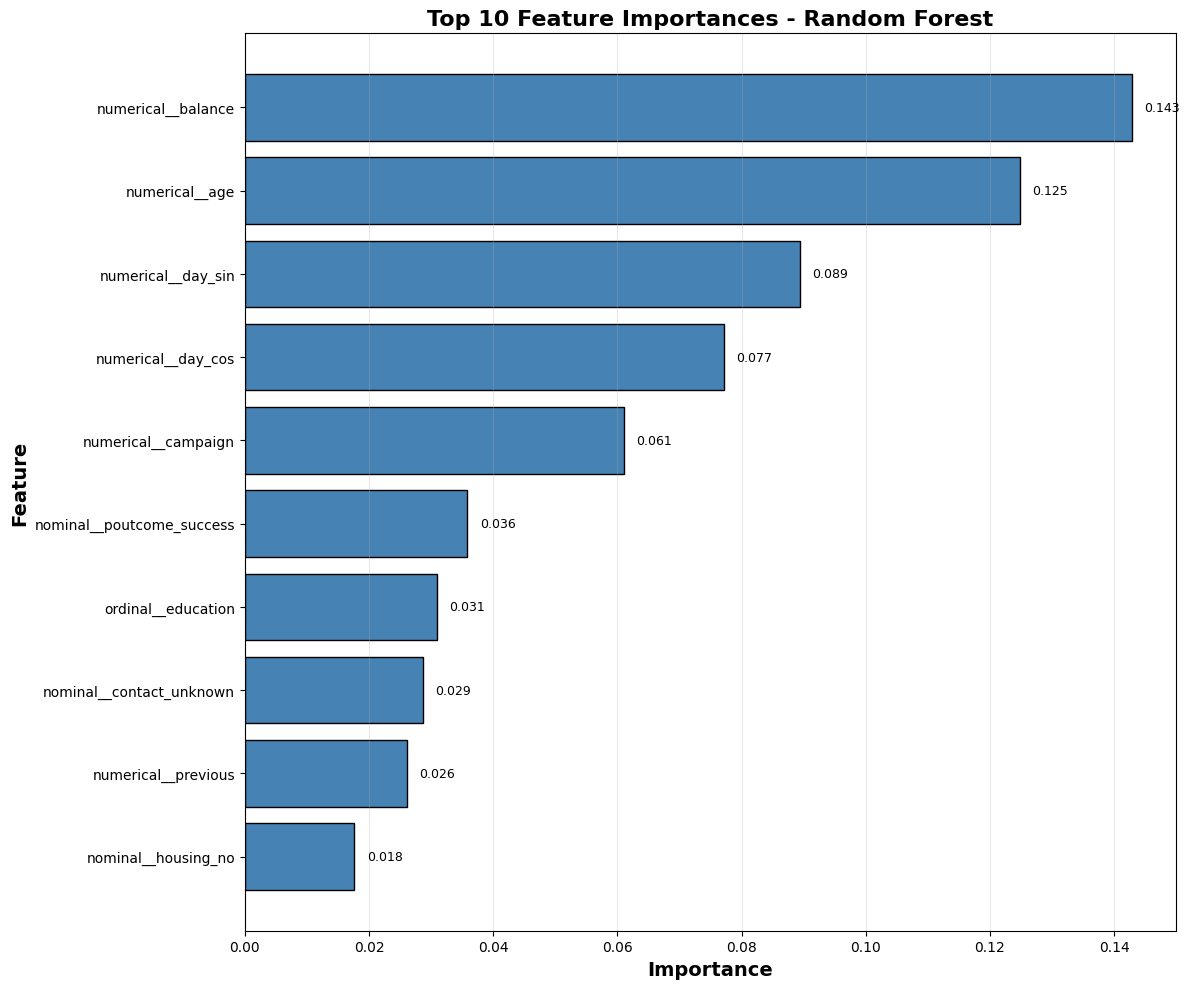

Top 10 Most Important Features:
                  Feature  Importance
       numerical__balance    0.142866
           numerical__age    0.124861
       numerical__day_sin    0.089439
       numerical__day_cos    0.077131
      numerical__campaign    0.061012
nominal__poutcome_success    0.035825
       ordinal__education    0.030901
 nominal__contact_unknown    0.028734
      numerical__previous    0.026106
      nominal__housing_no    0.017655


In [42]:
feature_names = X_train.columns
importances = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

top_features = feature_importance_df.head(10)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(top_features['Feature'], top_features['Importance'],
               color='steelblue', edgecolor='black')

for bar, val in zip(bars, top_features['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='left', va='center', fontsize=9)

ax.set_xlabel('Importance', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature', fontsize=14, fontweight='bold')
ax.set_title(f'Top 10 Feature Importances - {best_model_name}', fontsize=16, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('img/outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 Most Important Features:")
print(top_features.to_string(index=False))

**day-of-month**, correctly encoded, is one of the strongest predictors in the model — combined, it now sits between age and balance, ahead of campaign, poutcome_success, and everything else. ertain days of the month — plausibly paydays or billing cycles — correlate with subscribing

**Confusion Matrix**
(business impact (FP = wasted marketing calls, FN = missed customers))

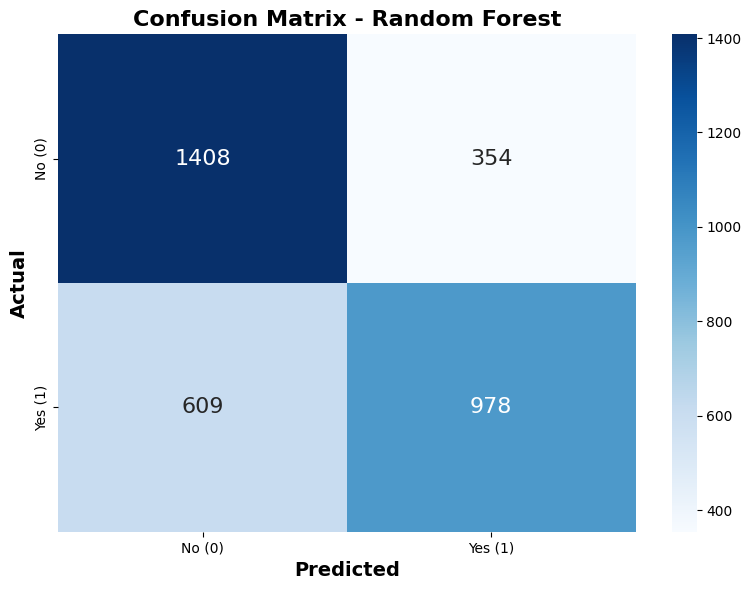

Confusion Matrix Breakdown:
  True Negatives (TN): 1408  - correctly predicted NON-subscribers
  True Positives (TP): 978  - correctly predicted SUBSCRIBERS
  False Positives (FP): 354 - wrongly predicted as subscribers (Type I error)
  False Negatives (FN): 609 - missed subscribers (Type II error)

Business Metrics:
  Precision: 0.7342 - when the model predicts YES, it is correct 73.4% of the time
  Recall: 0.6163 - finds 61.6% of actual subscribers
  Accuracy: 0.7125


In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_encoded, y_pred_encoded)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Yes (1)'],
            yticklabels=['No (0)', 'Yes (1)'],
            annot_kws={'size': 16})
plt.xlabel('Predicted', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=14, fontweight='bold')
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('img/outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix Breakdown:")
print(f"  True Negatives (TN): {tn}  - correctly predicted NON-subscribers")
print(f"  True Positives (TP): {tp}  - correctly predicted SUBSCRIBERS")
print(f"  False Positives (FP): {fp} - wrongly predicted as subscribers (Type I error)")
print(f"  False Negatives (FN): {fn} - missed subscribers (Type II error)")

print(f"\nBusiness Metrics:")
print(f"  Precision: {tp/(tp+fp):.4f} - when the model predicts YES, it is correct {tp/(tp+fp)*100:.1f}% of the time")
print(f"  Recall: {tp/(tp+fn):.4f} - finds {tp/(tp+fn)*100:.1f}% of actual subscribers")
print(f"  Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}")

#### Precision-Recall Curve

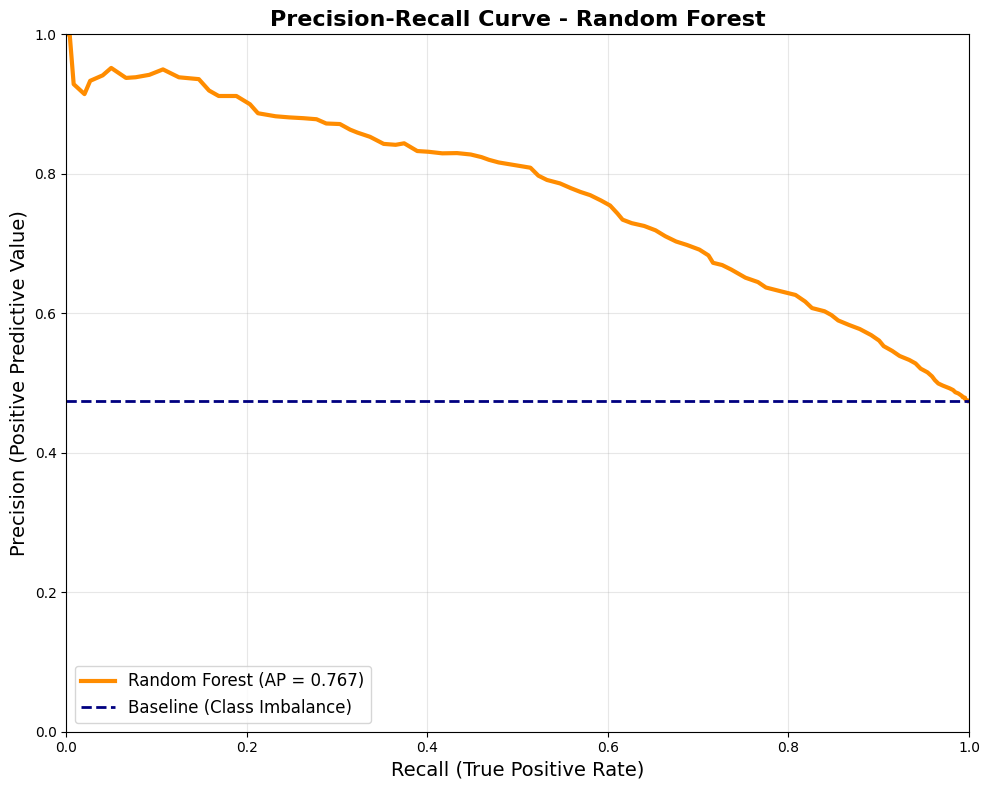

Average Precision: 0.7668
Precision at 50% Recall: 0.812


In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(y_test_encoded, y_proba)
avg_precision = average_precision_score(y_test_encoded, y_proba)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='darkorange', linewidth=3,
         label=f'{best_model_name} (AP = {avg_precision:.3f})')
plt.axhline(y=sum(y_train_encoded)/len(y_train_encoded), color='navy',
            linestyle='--', linewidth=2, label='Baseline (Class Imbalance)')

plt.xlabel('Recall (True Positive Rate)', fontsize=14)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=14)
plt.title(f'Precision-Recall Curve - {best_model_name}', fontsize=16, fontweight='bold')
plt.legend(loc='lower left', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('img/outputs/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average Precision: {avg_precision:.4f}")
print(f"Precision at 50% Recall: {precision[np.argmin(np.abs(recall - 0.5))]:.3f}")

At low recall levels — identifying the top 15–20% most confident predictions — precision stays above 90%, meaning these highest-scored clients are almost always genuine subscribers. As the model is asked to identify a larger share of clients, moving right along the recall axis, precision declines gradually rather than dropping sharply at any one point. Because there's no clear "elbow" in the curve, there's no threshold the chart itself flags as correct — choosing where to operate on this curve is a business decision (how much a wasted call costs vs. how much a missed subscriber is worth), not something the curve resolves on its own.

#### Calibration Curve

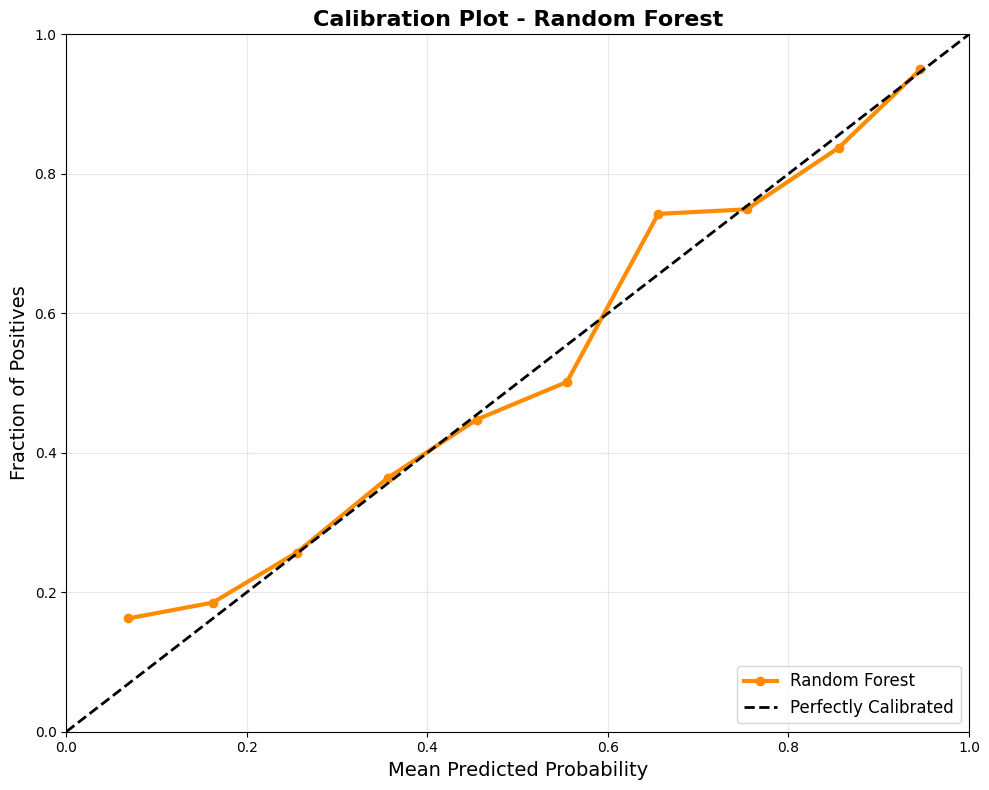

In [45]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_encoded, y_proba, n_bins=10)

plt.figure(figsize=(10, 8))
plt.plot(prob_pred, prob_true, 'o-', color='darkorange', linewidth=3,
         label=best_model_name)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability', fontsize=14)
plt.ylabel('Fraction of Positives', fontsize=14)
plt.title(f'Calibration Plot - {best_model_name}', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('img/outputs/calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

Points hug the diagonal closely across almost the entire range (0.25 to 0.55, and 0.75 to 0.95 are essentially on the line). The low end (0.07–0.25) still shows mild underconfidence, same pattern as before, where actual outcomes run slightly higher than predicted. Overall, this model's probability outputs can be trusted fairly directly for ranking or scoring clients